## Space X Falcon 9 First Stage Landing Prediction

Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch. In this lab, you will create a machine learning pipeline to predict if the first stage will land given the data from the preceding labs.

### Objectives
Perform exploratory Data Analysis and determine Training Labels

- create a column for the class
- Standardize the data
- Split into training data and test data
- Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

Find the method performs best using test data

### Import Libraries and Define Auxiliary Functions

In [1]:
# Logistic Regression
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn
!pip install matplotlib
!pip install plotly


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

ModuleNotFoundError: No module named 'matplotlib.backends.registry'

In [3]:
import sys

In [4]:
print("Número de módulos carregados:", len(sys.modules))

Número de módulos carregados: 1360


In [5]:
dir(GridSearchCV)[:10]

NameError: name 'GridSearchCV' is not defined

In [72]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

### Load the dataframe

In [81]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

In [82]:
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

### TASK 1

Create a NumPy array from the column Class in data, by applying the method to_numpy() then assign it to the variable Y,make sure the output is a Pandas series (only one bracket df['name of column']).

In [84]:
Y = data['Class'].to_numpy()

### TASK 2
Standardize the data in X then reassign it to the variable X using the transform provided below.

In [85]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

### TASK 3
We split the data into training and testing data using the function train_test_split. The training data is divided into validation data, a second set used for training data; then the models are trained and hyperparameters are selected using the function GridSearchCV.

In [86]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [87]:
Y_test.shape

(18,)

In [88]:
Y_train.shape

(72,)

### TASK 4
Create a logistic regression object then create a GridSearchCV object logreg_cv with cv = 10. Fit the object to find the best parameters from the dictionary parameters.

In [89]:
LR = LogisticRegression().fit(X_train,Y_train)

In [90]:
yhat = LR.predict(X_test)
yhat[:10]

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [91]:
yhat_prob = LR.predict_proba(X_test)
yhat_prob[:10]

array([[0.05753393, 0.94246607],
       [0.04871098, 0.95128902],
       [0.00359033, 0.99640967],
       [0.01236173, 0.98763827],
       [0.00723035, 0.99276965],
       [0.00854351, 0.99145649],
       [0.00930837, 0.99069163],
       [0.95093754, 0.04906246],
       [0.02864889, 0.97135111],
       [0.89731187, 0.10268813]])

In [93]:
coeficientes = LR.coef_[0]

# 2. Mapear para os nomes das colunas (se X_train for um DataFrame)
# Se for numpy array, use apenas range(len(coeficientes))
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else range(len(coeficientes))

# 3. Criar uma Series para facilitar a ordenação e plotagem
feature_importance = pd.Series(coeficientes, index=feature_names).sort_values(ascending=True)


C:\Users\CARLOS\AppData\Local\Temp\ipykernel_13612\981371397.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  feature_importance.plot(kind='barh', color=colors)


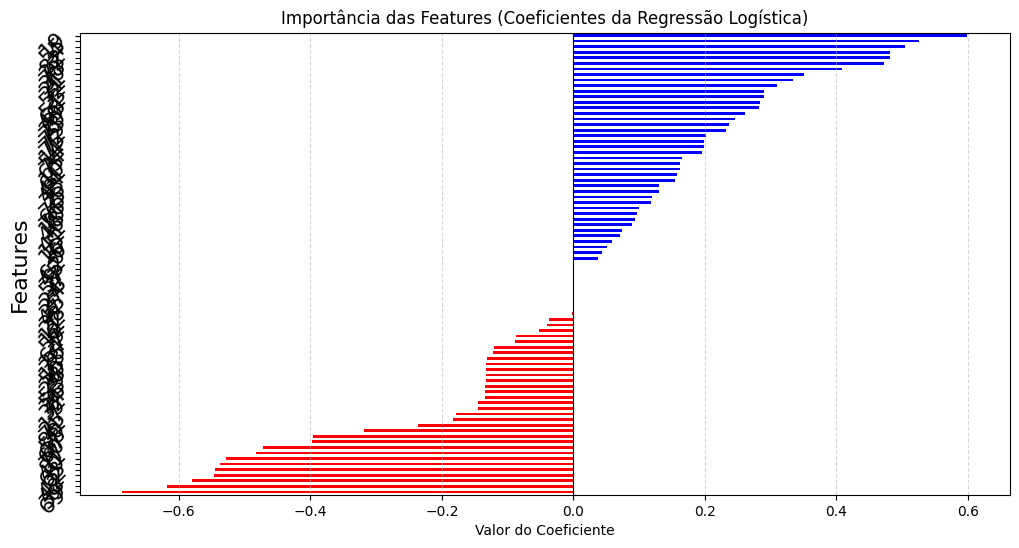

In [103]:
# Definir o tamanho do gráfico
plt.figure(figsize=(12, 6))

# Plotar coeficientes positivos e negativos
colors = ['red' if c < 0 else 'blue' for c in feature_importance]
feature_importance.plot(kind='barh', color=colors)

plt.title('Importância das Features (Coeficientes da Regressão Logística)')
plt.xlabel('Valor do Coeficiente')
plt.ylabel('Features', fontsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.yticks(rotation=45)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='black', linewidth=0.8) # Linha central no zero


We output the GridSearchCV object for logistic regression. We display the best parameters using the data attribute best_params_ and the accuracy on the validation data using the data attribute best_score_.

In [104]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

In [6]:
logreg_cv = GridSearchCV(
    estimator=LR, param_grid=parameters, 
    cv=10,  
    scoring='accuracy',  
    n_jobs=-1             
)

NameError: name 'GridSearchCV' is not defined

In [7]:
logreg_cv.fit(X_train, Y_train)

NameError: name 'logreg_cv' is not defined

In [18]:
best_model = GridSearchCV(estimator=lr,
                          param_grid=parameters,
                          cv=10,
                          scoring='accuracy',
                          verbose=2
                         )

In [19]:
best_model.fit(X_train, Y_train)

Fitting 10 folds for each of 3 candidates, totalling 30 fits
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ...................C=0.01, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, solver=lbfgs; total time=   0.0s
[CV] END ....................C=0.1, penalty=l2, 

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l2'], 'solver': ['lbfgs']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [20]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


In [21]:
accuracy = best_model.score(X_test, Y_test)

In [22]:
print("accuracy score method:",accuracy)

accuracy score method: 0.8333333333333334


In [23]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

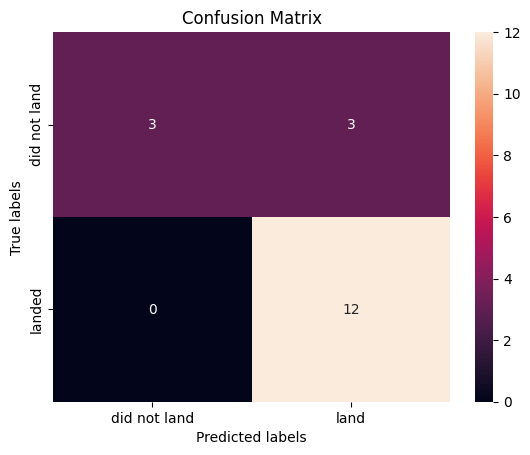

In [24]:
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [35]:
coefficients = pd.Series(lr.coef_[0], index=data.columns[:-1])
coefficients.sort_values().plot(kind='barh')
plt.title("Feature Coefficients in Logistic Regression Churn Model")
plt.xlabel("Coefficient Value")
plt.show()

ValueError: Length of values (83) does not match length of index (17)

In [25]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()

In [26]:
knn_cv = GridSearchCV(
    estimator=KNN, param_grid=parameters, cv=10, # Número de folds da validação cruzada
    scoring='accuracy', # Métrica de avaliação
    n_jobs=-1            # Usa todos os núcleos do processador
)

In [27]:
knn_cv = GridSearchCV(KNN,parameters,cv=10)
knn_cv.fit(X_train, Y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'n_neighbors': [1, 2, ...], 'p': [1, 2]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,10


In [28]:
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


In [29]:
accuracy = knn_cv.score(X_test, Y_test)

In [30]:
accuracy

0.8333333333333334

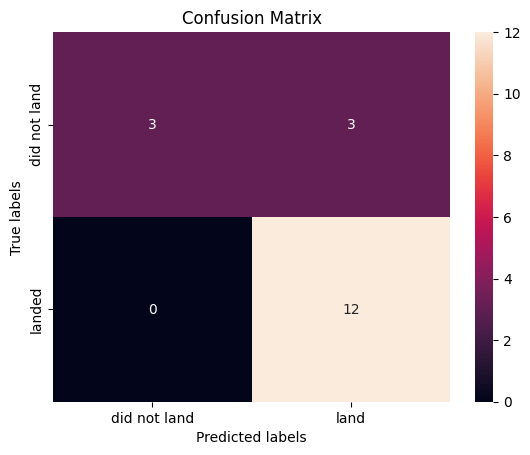

In [31]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [32]:

print("Logistic Regression Accuracy :",logreg_cv.best_score_)
print("KNeighborsClassifiers Accuracy :",knn_cv.best_score_)

Logistic Regression Accuracy : 0.8464285714285713
KNeighborsClassifiers Accuracy : 0.8482142857142858
